In [47]:
import os
import sys
from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pickle
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [48]:
model_u, model_k = build_models_KAN(
    device,
    hidden_layers=4,
    hidden_units=9,
    grid_size=3,
    spline_order=3,
)

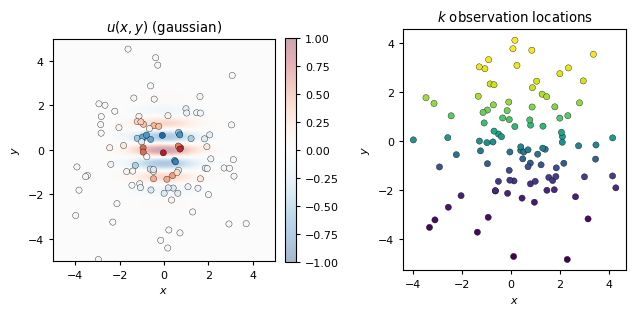

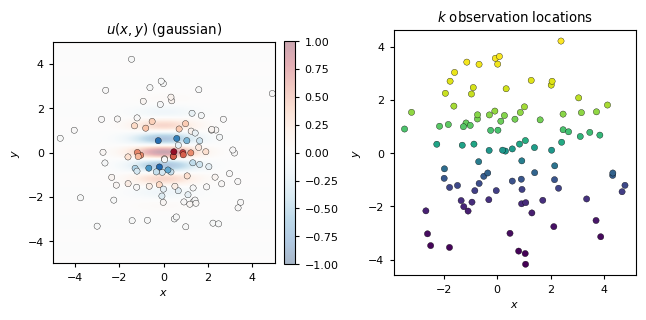

In [49]:
# Training data
(
    X_obs_train,
    U_obs_train,
    X_obs_k_train,
    K_obs_train,
    X_pde_train,
    F_pde_train,
    *_,
) = generate_dataset_inf(
    n_obs_u=100,
    n_obs_k=100,
    n_pde=1000,
    plot=True,
    device=device,
    sampling="gaussian"
)

# Test data
(
    X_obs_test,
    U_obs_test,
    X_obs_k_test,
    K_obs_test,
    X_pde_test,
    F_pde_test,
    *_,
) = generate_dataset_inf(
    n_obs_u=100,
    n_obs_k=100,
    n_pde=1000,
    plot=True,
    device=device,
    sampling="gaussian"
)

In [50]:
history = train_dual_network(
    model_u,
    model_k,
    X_obs_train,
    U_obs_train,
    X_obs_k_train,
    K_obs_train,
    X_pde_train,
    F_pde_train,
    X_obs_test,
    U_obs_test,
    X_obs_k_test,
    K_obs_test,
    X_pde_test,
    F_pde_test,
    adam_lr=1e-4,
    adam_iters=3000,
    lbfgs_iters=3000,
    adaptive_weights=True,
    verbose=True,
    regularization=False,
)


Training with Adam
V      = [7.50000e-02 4.23700e+00 1.66508e+02]
R      = [0.    0.025 1.   ]
ratio  = 2230.42
lambda = [  1.      3.501 101.   ]
Adam     0 | Total=1.683e+04 | ObsU=7.465e-02 | ObsK=4.237e+00 | PDE=1.665e+02 | Ratio=2230.42
V      = [7.50000e-02 4.10200e+00 1.66506e+02]
R      = [0.    0.024 1.   ]
ratio  = 2228.78
lambda = [  1.     3.42 101.  ]
Adam   100 | Total=1.683e+04 | ObsU=7.520e-02 | ObsK=3.945e+00 | PDE=1.665e+02 | Ratio=2228.78
V      = [7.80000e-02 3.72700e+00 1.66486e+02]
R      = [0.    0.022 1.   ]
ratio  = 2144.15
lambda = [  1.      3.193 101.   ]
Adam   200 | Total=1.682e+04 | ObsU=8.249e-02 | ObsK=3.455e+00 | PDE=1.665e+02 | Ratio=2144.15
V      = [9.90000e-02 3.06000e+00 1.66336e+02]
R      = [0.    0.018 1.   ]
ratio  = 1675.44
lambda = [  1.      2.781 101.   ]
Adam   300 | Total=1.679e+04 | ObsU=1.292e-01 | ObsK=2.572e+00 | PDE=1.661e+02 | Ratio=1675.44
V      = [  0.21    1.996 165.262]
R      = [0.    0.011 1.   ]
ratio  = 785.72
lambda = [ 

Relative L2 error (u): 6.583e+00
Relative L2 error (k): 8.519e-01


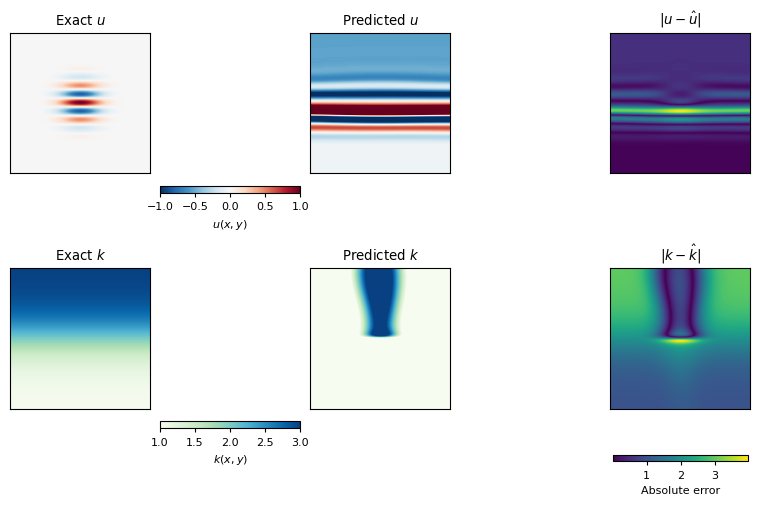

In [52]:
err_u, err_k = evaluate_model_inf(
    model_u,
    model_k,
    analytical_solution_inf,
    coefficient_inf,
    device=device,
    save_results=False,
    verbose=True,
    plot=True
)

In [53]:
with open("results/history_fixed_no_reg.pkl", "rb") as f:
    history_fixed_no_reg = pickle.load(f)

with open("results/history_fixed_reg.pkl", "rb") as f:
    history_fixed_reg = pickle.load(f)

with open("results/history_adaptive_reg.pkl", "rb") as f:
    history_adaptive_reg = pickle.load(f)

with open("results/history_adaptive_no_reg.pkl", "rb") as f:
    history_adaptive_no_reg = pickle.load(f)

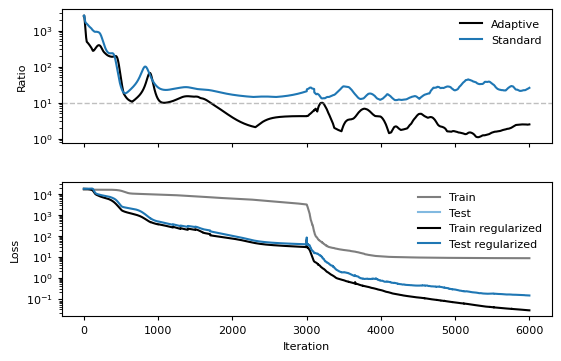

In [54]:

fig, ax = plt.subplots(
    2, 1,
    figsize=(5.5, 3.5),
    sharex=True,
    constrained_layout=True,
)

fig.set_constrained_layout_pads(hspace=0.2)

# --------------------------------------------------
# Top panel: Ratio
# --------------------------------------------------

ax[0].plot(
    history_adaptive_reg["ratio"],
    label="Adaptive",
    color="black",
)

ax[0].plot(
    history_fixed_reg["ratio"],
    label="Standard",
    color="#1f77b4",
)

ax[0].axhline(
    y=10.0,
    color="gray",
    linestyle="--",
    lw=1,
    alpha=0.5,
)

ax[0].set_ylabel("Ratio")
ax[0].set_yscale("log")
ax[0].legend(frameon=False)
#ax[0].set_title("Ratio comparison between adaptive and standard training", fontsize=9)

# --------------------------------------------------
# Bottom panel: Loss
# --------------------------------------------------

ax[1].plot(
    history_adaptive_no_reg["total_no_reg"],
    label="Train",
    color="#7E7E7E",
)

ax[1].plot(
    history_adaptive_no_reg["total_no_reg_test"],
    label="Test",
    color="#81b9e0",
)

ax[1].plot(
    history_adaptive_reg["total_no_reg"],
    label="Train regularized",
    color="black",
)

ax[1].plot(
    history_adaptive_reg["total_no_reg_test"],
    label="Test regularized",
    color="#1f77b4",
)

ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Loss")
ax[1].set_yscale("log")
ax[1].legend(frameon=False)
#ax[1].set_title("Regularized", fontsize=9)
plt.savefig("figures/ratio_loss_comparison.png", dpi=300, bbox_inches='tight')
plt.show()